# SIMG · Track HPC / Efficient ML · Sesión 02
# Profiling de kernels en Triton

**Escribir el kernel es la mitad del trabajo. La otra mitad es *medir*.**

En GPU la intuición engaña: un kernel puede *parecer* rápido y estar
desperdiciando el 90 % de la máquina. Este notebook enseña a responder, con
números y no con corazonadas, tres preguntas:

1. **¿Cuánto tarda de verdad?** — medir tiempo sin mentirnos (`do_bench`).
2. **¿Contra qué límite choco?** — ¿memoria o cómputo? (ancho de banda vs FLOP/s, *roofline*).
3. **¿Por qué?** — mirar dentro del kernel compilado y del *timeline* de ejecución.

> Material del Semillero de Investigación en *High Performance Computing*.

### ▶ Cómo correrlo en Google Colab

Colab ya trae **PyTorch + Triton** instalados; no hay que instalar nada.

1. Sube este `.ipynb` a [colab.research.google.com](https://colab.research.google.com) (*Archivo → Subir notebook*).
2. Activa la GPU: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → Acelerador por hardware: GPU (T4)**.
3. Ejecuta las celdas en orden (*Entorno de ejecución → Ejecutar todas*).

> **Importante:** sin GPU el notebook no funciona — la celda de verificación de
> abajo te avisará. Los números (ancho de banda, TFLOP/s) dependen de la GPU que
> te toque en Colab (T4, L4, etc.); lo que importa es el *método*, no el valor exacto.

## 0 · Verificación del entorno

Si algo falla aquí, falla todo lo demás. `do_bench` y `perf_report` viven en
`triton.testing`; para las gráficas hacen falta `matplotlib` y `pandas`.

In [1]:
import torch
import triton
import triton.language as tl

# ¿Estamos en Colab? (solo para dar mensajes más útiles)
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if not torch.cuda.is_available():
    msg = "No hay GPU disponible."
    if EN_COLAB:
        msg += (" En Colab: Entorno de ejecución -> Cambiar tipo de entorno"
                " de ejecución -> GPU (T4), y vuelve a ejecutar esta celda.")
    raise RuntimeError(msg)

DEVICE = "cuda"
print("Entorno  :", "Google Colab" if EN_COLAB else "local")
print("PyTorch  :", torch.__version__)
print("Triton   :", triton.__version__)
print("GPU      :", torch.cuda.get_device_name(0))

# Este notebook se probó con Triton 3.x. Versiones muy antiguas (2.x) pueden
# tener APIs distintas en la sección 6 (introspección del kernel compilado).
if int(triton.__version__.split('.')[0]) < 3:
    print("\n[aviso] Triton < 3.0: casi todo funciona, pero la introspeccion"
          " del kernel (seccion 6) podria diferir.")

# Propiedades útiles para interpretar los números más abajo.
props = torch.cuda.get_device_properties(0)
print(f"SMs      : {props.multi_processor_count}")
print(f"VRAM     : {props.total_memory / 1e9:.1f} GB")

Entorno  : local
PyTorch  : 2.8.0+cu128
Triton   : 3.4.0
GPU      : NVIDIA GeForce RTX 3060
SMs      : 28
VRAM     : 12.5 GB


## 1 · El marco mental: ¿qué significa "rápido"?

Un kernel choca contra **uno de dos techos**:

| Tipo | Cuello de botella | Métrica clave | Ejemplos |
|------|-------------------|---------------|----------|
| **Memory-bound** | mover datos VRAM↔chip | **GB/s** (ancho de banda) | suma de vectores, *softmax*, *element-wise*, normalizaciones |
| **Compute-bound** | hacer operaciones aritméticas | **FLOP/s** | *matmul* grande, convoluciones |

La herramienta para saber en cuál estás es la **intensidad aritmética**:

$$ I = \frac{\text{FLOPs realizados}}{\text{bytes movidos}} \quad [\text{FLOP/byte}] $$

- **Intensidad baja** → mueves muchos bytes por cada cuenta → *memory-bound*.
- **Intensidad alta** → reutilizas mucho cada byte cargado → *compute-bound*.

Esto se dibuja en el **modelo Roofline**: si tu kernel toca el "techo inclinado"
(ancho de banda) o el "techo plano" (cómputo pico), está optimizado **para su
intensidad**. Si está muy por debajo de ambos, hay trabajo que hacer.

> **Regla práctica:** antes de optimizar, decide qué techo te limita. Optimizar
> el cómputo de un kernel memory-bound es tirar el tiempo.

## 2 · Los kernels que vamos a perfilar

Para que el notebook sea **autocontenido** (corre tal cual en Colab) definimos
aquí dos kernels representativos, uno de cada tipo:

- `add` → **suma de vectores**: el caso memory-bound de manual.
- `matmul` → **multiplicación de matrices**: el caso compute-bound estrella.

(Son los mismos de `kernels/01_vector_add.py` y `kernels/03_matmul.py`.)

In [2]:
# ── Memory-bound: z = x + y ──────────────────────────────────────────────
@triton.jit
def add_kernel(x_ptr, y_ptr, out_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(0)
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    tl.store(out_ptr + offsets, x + y, mask=mask)


def add(x, y, block_size=1024):
    out = torch.empty_like(x)
    n = out.numel()
    grid = lambda meta: (triton.cdiv(n, meta["BLOCK_SIZE"]),)
    add_kernel[grid](x, y, out, n, BLOCK_SIZE=block_size)
    return out

In [3]:
# ── Compute-bound: C = A @ B ─────────────────────────────────────────────
@triton.jit
def matmul_kernel(a_ptr, b_ptr, c_ptr, M, N, K,
                  stride_am, stride_ak, stride_bk, stride_bn,
                  stride_cm, stride_cn,
                  BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr, BLOCK_K: tl.constexpr):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)
    a_ptrs = a_ptr + (offs_m[:, None] * stride_am + offs_k[None, :] * stride_ak)
    b_ptrs = b_ptr + (offs_k[:, None] * stride_bk + offs_n[None, :] * stride_bn)
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, tl.cdiv(K, BLOCK_K)):
        k_rem = K - k * BLOCK_K
        a = tl.load(a_ptrs, mask=offs_k[None, :] < k_rem, other=0.0)
        b = tl.load(b_ptrs, mask=offs_k[:, None] < k_rem, other=0.0)
        acc += tl.dot(a, b)
        a_ptrs += BLOCK_K * stride_ak
        b_ptrs += BLOCK_K * stride_bk
    c = acc.to(tl.float16)
    c_ptrs = c_ptr + offs_m[:, None] * stride_cm + offs_n[None, :] * stride_cn
    mask = (offs_m[:, None] < M) & (offs_n[None, :] < N)
    tl.store(c_ptrs, c, mask=mask)


def matmul(a, b, BLOCK_M=64, BLOCK_N=64, BLOCK_K=32):
    M, K = a.shape
    K, N = b.shape
    c = torch.empty((M, N), device=a.device, dtype=torch.float16)
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))
    matmul_kernel[grid](a, b, c, M, N, K,
                        a.stride(0), a.stride(1), b.stride(0), b.stride(1),
                        c.stride(0), c.stride(1),
                        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K)
    return c

In [4]:
# Comprobación rápida de correctitud antes de medir nada.
torch.manual_seed(0)
x = torch.rand(2**20, device=DEVICE)
y = torch.rand(2**20, device=DEVICE)
assert torch.allclose(add(x, y), x + y), "add incorrecto"

a = torch.randn((512, 512), device=DEVICE, dtype=torch.float16)
b = torch.randn((512, 512), device=DEVICE, dtype=torch.float16)
assert torch.allclose(matmul(a, b), a @ b, atol=1e-1, rtol=1e-1), "matmul incorrecto"
print("✓ Ambos kernels producen resultados correctos. Ahora sí, a medir.")

✓ Ambos kernels producen resultados correctos. Ahora sí, a medir.


### El dato que da sentido a todo lo demás: el ancho de banda alcanzable

Casi todos los kernels sencillos están **limitados por memoria**, no por cómputo.
Por eso el primer número que conviene conocer es el **ancho de banda de streaming
alcanzable**: cuántos GB/s logra mover la GPU en operaciones que solo recorren la
memoria. Lo estimamos empíricamente probando varias operaciones de *streaming*
(una copia y el propio kernel a tamaño grande) y quedándonos con el mejor valor:
ese es el **techo realista** contra el que comparar.

In [5]:
def medir_ancho_banda_pico():
    """Mejor GB/s de streaming alcanzable: barremos varios tamaños grandes con
    una copia y con el propio kernel `add`, y nos quedamos con el MÁXIMO. Como
    el ancho de banda varía con el tamaño, un solo punto no basta; el máximo del
    barrido es un techo realista para cualquier kernel limitado por memoria."""
    mejor = 0.0
    for n in [2**22, 2**23, 2**24, 2**25, 2**26]:   # 4 M → 64 M elementos
        x = torch.rand(n, device=DEVICE, dtype=torch.float32)
        y = torch.rand(n, device=DEVICE, dtype=torch.float32)
        ms_copy = triton.testing.do_bench(lambda: x.clone())   # mueve 2 buffers
        ms_add  = triton.testing.do_bench(lambda: add(x, y))   # mueve 3 buffers
        bw_copy = 2 * n * x.element_size() / (ms_copy * 1e-3) / 1e9
        bw_add  = 3 * n * x.element_size() / (ms_add  * 1e-3) / 1e9
        mejor = max(mejor, bw_copy, bw_add)
    return mejor

BW_PICO = medir_ancho_banda_pico()
print(f"Ancho de banda de streaming alcanzable: ~{BW_PICO:.0f} GB/s")
print("Guarda este número: es el techo de cualquier kernel limitado por memoria.")

Ancho de banda de streaming alcanzable: ~322 GB/s
Guarda este número: es el techo de cualquier kernel limitado por memoria.


## 3 · Medir tiempo SIN engañarnos: `triton.testing.do_bench`

La tentación es `t0 = time.time(); kernel(); print(time.time() - t0)`. **Está mal**
por varias razones, y todas importan en GPU:

1. **Asincronía** — los lanzamientos CUDA son *asíncronos*: `time.time()` mide
   cuánto tardó en *encolar* el kernel, no en ejecutarlo. Haría falta
   `torch.cuda.synchronize()`.
2. **Warmup** — la primera ejecución incluye compilación JIT, *autotuning* y
   carga del kernel. No es representativa.
3. **Ruido** — el reloj de la GPU varía; una sola medición es poco fiable.
4. **Caché L2** — si repites con el mismo buffer, los datos quedan en L2 y mides
   un ancho de banda irrealmente alto.

`do_bench` resuelve **las cuatro**: hace warmup, usa *CUDA events* (precisos y
conscientes de la asincronía), repite muchas veces, **vacía la L2 entre
iteraciones** y devuelve **cuantiles** en milisegundos.

In [6]:
import time

x = torch.rand(2**24, device=DEVICE)   # 16 M elementos
y = torch.rand(2**24, device=DEVICE)

# ── Forma INGENUA (incorrecta) ───────────────────────────────────────────
t0 = time.time()
add(x, y)
naive_ms = (time.time() - t0) * 1e3

# ── Forma INGENUA pero con sincronización ────────────────────────────────
torch.cuda.synchronize()
t0 = time.time()
add(x, y)
torch.cuda.synchronize()
sync_ms = (time.time() - t0) * 1e3

# ── Forma CORRECTA ───────────────────────────────────────────────────────
ms = triton.testing.do_bench(lambda: add(x, y))

print(f"time.time() sin sync : {naive_ms:8.4f} ms  ← incluye solo el encolado (engañoso)")
print(f"time.time() con sync : {sync_ms:8.4f} ms  ← incluye overhead de lanzamiento")
print(f"do_bench             : {ms:8.4f} ms  ← el número en el que confiar")

time.time() sin sync :   0.1590 ms  ← incluye solo el encolado (engañoso)
time.time() con sync :   0.6821 ms  ← incluye overhead de lanzamiento
do_bench             :   0.6111 ms  ← el número en el que confiar


### Cuantiles: la mediana y la dispersión

Pasando `quantiles=[0.5, 0.2, 0.8]` obtienes mediana, p20 y p80. La **mediana**
es más robusta que la media frente a *outliers*; el rango p20–p80 te dice si la
medición es estable o ruidosa.

In [7]:
ms, min_ms, max_ms = triton.testing.do_bench(
    lambda: add(x, y), quantiles=[0.5, 0.2, 0.8]
)
print(f"mediana: {ms:.4f} ms   |   p20: {min_ms:.4f} ms   |   p80: {max_ms:.4f} ms")

# Convertimos el tiempo en una métrica interpretable: ancho de banda efectivo.
# add mueve 3 buffers (leer x, leer y, escribir z) * 4 bytes (fp32).
gbps = 3 * x.numel() * x.element_size() / (ms * 1e-3) / 1e9
print(f"\nAncho de banda efectivo: {gbps:.0f} GB/s")
ef = 100 * gbps / BW_PICO
print(f"Frente al techo de streaming: {ef:.0f} %  (techo ~{BW_PICO:.0f} GB/s)")
print("≈100 % ⇒ el kernel satura la memoria. En GPUs con boost de reloj dinámico")
print("hay ~±5 % de ruido entre dos mediciones, por eso puede rondar el 100 %.")

mediana: 0.6011 ms   |   p20: 0.6001 ms   |   p80: 0.6011 ms

Ancho de banda efectivo: 335 GB/s
Frente al techo de streaming: 104 %  (techo ~322 GB/s)
≈100 % ⇒ el kernel satura la memoria. En GPUs con boost de reloj dinámico
hay ~±5 % de ruido entre dos mediciones, por eso puede rondar el 100 %.


> **Lectura del resultado:** si la suma de vectores alcanza prácticamente el
> mismo ancho de banda que el mejor streaming posible (~100 %), **está
> esencialmente optimizada**: es memory-bound y ya satura la memoria. No hay
> nada que ganar tocando la aritmética.

## 4 · Barrido de ancho de banda con `triton.testing.perf_report`

Una sola medición es una foto; lo interesante es la **curva** en función del
tamaño. `perf_report` + `Benchmark` automatiza el barrido, compara *providers*
(Triton vs PyTorch) y dibuja la gráfica.

Fíjate en la forma: con vectores **pequeños** domina el *overhead* de lanzar el
kernel (poco ancho de banda); al **crecer**, la curva sube y se aplana al tocar
el techo de memoria.

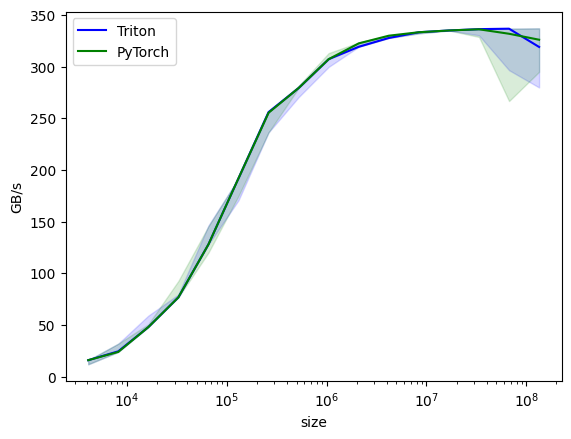

vector-add-bandwidth:
           size      Triton     PyTorch
0        4096.0   15.999999   15.999999
1        8192.0   24.575999   24.000000
2       16384.0   48.000000   48.000000
3       32768.0   76.800002   76.800002
4       65536.0  127.999995  127.999995
5      131072.0  192.000000  192.000000
6      262144.0  255.999991  255.335070
7      524288.0  279.272725  279.272725
8     1048576.0  307.200008  307.200008
9     2097152.0  319.168844  322.440352
10    4194304.0  327.679984  329.879196
11    8388608.0  333.233892  333.233892
12   16777216.0  334.936975  334.936975
13   33554432.0  336.234724  336.082067
14   67108864.0  336.657521  331.757856
15  134217728.0  318.979707  325.982179


In [8]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["size"],
        x_vals=[2**i for i in range(12, 28, 1)],   # 4K → 128M
        x_log=True,
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "PyTorch"],
        styles=[("blue", "-"), ("green", "-")],
        ylabel="GB/s",
        plot_name="vector-add-bandwidth",
        args={},
    )
)
def bench_add(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    q = [0.5, 0.2, 0.8]
    if provider == "torch":
        ms, mn, mx = triton.testing.do_bench(lambda: x + y, quantiles=q)
    else:
        ms, mn, mx = triton.testing.do_bench(lambda: add(x, y), quantiles=q)
    gbps = lambda t: 3 * x.numel() * x.element_size() / (t * 1e-3) / 1e9
    return gbps(ms), gbps(mx), gbps(mn)

bench_add.run(print_data=True, show_plots=True)

## 5 · El otro techo: rendimiento de cómputo (TFLOP/s) en `matmul`

El matmul es **compute-bound** cuando las matrices son grandes: por cada byte
cargado se hacen muchísimas multiplicaciones-acumulaciones. Aquí la métrica que
importa no es GB/s sino **TFLOP/s**.

Para una multiplicación $M\times K$ por $K\times N$ se hacen $2MNK$ operaciones
en coma flotante (un multiply + un add por cada término). Comparamos nuestro
kernel didáctico contra cuBLAS (`torch.matmul`), que es la referencia industrial.

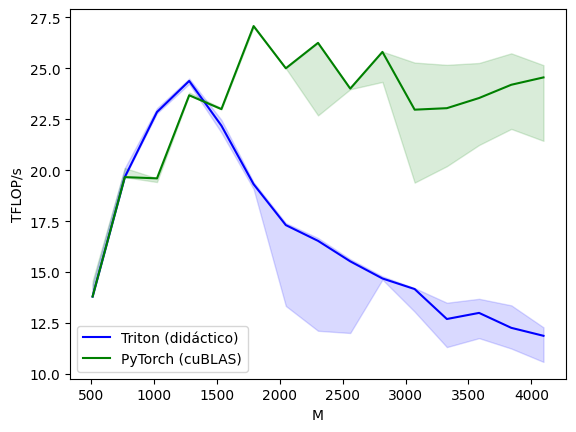

matmul-throughput:
         M       N       K  Triton (didáctico)  PyTorch (cuBLAS)
0    512.0   512.0   512.0           13.797053         13.797053
1    768.0   768.0   768.0           19.660800         19.660800
2   1024.0  1024.0  1024.0           22.857242         19.599551
3   1280.0  1280.0  1280.0           24.380953         23.678440
4   1536.0  1536.0  1536.0           22.187736         22.998825
5   1792.0  1792.0  1792.0           19.311725         27.075813
6   2048.0  2048.0  2048.0           17.305019         25.003303
7   2304.0  2304.0  2304.0           16.531400         26.250409
8   2560.0  2560.0  2560.0           15.525719         24.005860
9   2816.0  2816.0  2816.0           14.684918         25.807224
10  3072.0  3072.0  3072.0           14.164629         22.971416
11  3328.0  3328.0  3328.0           12.694569         23.044589
12  3584.0  3584.0  3584.0           12.994434         23.543261
13  3840.0  3840.0  3840.0           12.261009         24.194268
14  40

In [9]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["M", "N", "K"],
        x_vals=[256 * i for i in range(2, 17)],     # 512 → 4096
        x_log=False,
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton (didáctico)", "PyTorch (cuBLAS)"],
        styles=[("blue", "-"), ("green", "-")],
        ylabel="TFLOP/s",
        plot_name="matmul-throughput",
        args={},
    )
)
def bench_matmul(M, N, K, provider):
    a = torch.randn((M, K), device=DEVICE, dtype=torch.float16)
    b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    q = [0.5, 0.2, 0.8]
    if provider == "torch":
        ms, mn, mx = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=q)
    else:
        ms, mn, mx = triton.testing.do_bench(lambda: matmul(a, b), quantiles=q)
    tflops = lambda t: 2 * M * N * K / (t * 1e-3) / 1e12
    return tflops(ms), tflops(mx), tflops(mn)

bench_matmul.run(print_data=True, show_plots=True)

> **Lectura honesta del resultado:** el kernel didáctico va a ir *bastante por
> debajo* de cuBLAS. Eso es esperado y **educativo**: cuBLAS usa *autotuning*,
> doble *buffering*, *swizzling* de tiles y formas óptimas que aquí omitimos por
> claridad. La distancia entre ambas curvas **es justamente lo que mide el
> profiling**: cuánto rendimiento queda sobre la mesa.

## 6 · Mirar DENTRO del kernel compilado

`do_bench` te dice *cuánto* tarda; para entender *por qué*, hay que abrir el
binario que Triton generó. Cada kernel compilado expone metadatos clave:

- **`n_regs`** — registros por hilo. Demasiados → menos *occupancy* (menos
  bloques residentes por SM a la vez).
- **`n_spills`** — *register spills*: registros que no cupieron y se volcaron a
  memoria local (lenta). **Cualquier valor > 0 es una alerta.**
- **`shared`** — memoria compartida (SRAM) usada por bloque, en bytes.
- **`.asm`** — el código generado: `ttir` (Triton IR), `ttgir` (IR de GPU),
  `ptx` (ensamblador NVIDIA) y `cubin`.

In [10]:
# Compilamos un kernel concreto y le pedimos sus metadatos.
# Usamos getattr defensivo: la API exacta puede variar entre versiones de
# Triton (en Colab puede no ser la misma 3.4 con la que se escribió esto).
x = torch.rand(2**20, device=DEVICE)
y = torch.rand(2**20, device=DEVICE)
out = torch.empty_like(x)
n = out.numel()

# El operador [grid] devuelve el objeto del kernel compilado (CompiledKernel).
compiled = add_kernel[(triton.cdiv(n, 1024),)](x, y, out, n, BLOCK_SIZE=1024)

n_regs   = getattr(compiled, "n_regs", None)
n_spills = getattr(compiled, "n_spills", None)
shared   = getattr(getattr(compiled, "metadata", None), "shared", None)
asm      = getattr(compiled, "asm", {})

nd = lambda v: "n/d" if v is None else v
print(f"Registros por hilo (n_regs): {nd(n_regs)}")
spill_tag = "" if n_spills is None else ('  \u26a0\ufe0f hay spills!' if n_spills else '  \u2713 sin spills')
print(f"Register spills  (n_spills): {nd(n_spills)}{spill_tag}")
print(f"Memoria compartida (bytes) : {nd(shared)}")
print(f"Representaciones disponibles: {list(asm.keys())}")

Registros por hilo (n_regs): 26
Register spills  (n_spills): 0  ✓ sin spills
Memoria compartida (bytes) : 0
Representaciones disponibles: ['source', 'ttir', 'ttgir', 'llir', 'ptx', 'cubin']


In [11]:
# Las primeras líneas del PTX (ensamblador NVIDIA) generado.
ptx = compiled.asm["ptx"]
print("\n".join(ptx.splitlines()[:40]))

//
// Generated by LLVM NVPTX Back-End
//

.version 8.7
.target sm_86
.address_size 64

	// .globl	add_kernel              // -- Begin function add_kernel
                                        // @add_kernel
.visible .entry add_kernel(
	.param .u64 .ptr .global .align 1 add_kernel_param_0,
	.param .u64 .ptr .global .align 1 add_kernel_param_1,
	.param .u64 .ptr .global .align 1 add_kernel_param_2,
	.param .u32 add_kernel_param_3,
	.param .u64 .ptr .global .align 1 add_kernel_param_4
)
.reqntid 128
{
	.reg .pred 	%p<7>;
	.reg .b32 	%r<33>;
	.reg .b64 	%rd<11>;
	.loc	1 3 0                           // 4105984938.py:3:0
$L__func_begin0:
	.loc	1 3 0                           // 4105984938.py:3:0

// %bb.0:
	ld.param.b64 	%rd7, [add_kernel_param_0];
	ld.param.b64 	%rd8, [add_kernel_param_1];
$L__tmp0:
	.loc	1 4 24                          // 4105984938.py:4:24
	mov.u32 	%r25, %ctaid.x;
	.loc	1 5 20                          // 4105984938.py:5:20
	shl.b32 	%r26, %r25, 10;
	ld.param.b64 	%rd

### Experimento: cómo `BLOCK_SIZE` cambia el binario y el rendimiento

`BLOCK_SIZE` es un parámetro `tl.constexpr`: **cada valor genera un kernel
distinto**. Más grande = más trabajo por *program* (menos lanzamientos) pero más
presión de registros. Lo medimos en vez de adivinarlo.

In [12]:
x = torch.rand(2**24, device=DEVICE)
y = torch.rand(2**24, device=DEVICE)
n = x.numel()

print(f"{'BLOCK_SIZE':>10} | {'ms':>8} | {'GB/s':>6} | {'n_regs':>6} | {'spills':>6}")
print("-" * 52)
for bs in [128, 256, 512, 1024, 2048, 4096, 8192]:
    out = torch.empty_like(x)
    k = add_kernel[(triton.cdiv(n, bs),)](x, y, out, n, BLOCK_SIZE=bs)
    ms = triton.testing.do_bench(lambda: add(x, y, block_size=bs))
    gbps = 3 * n * x.element_size() / (ms * 1e-3) / 1e9
    regs = getattr(k, 'n_regs', '-')
    spills = getattr(k, 'n_spills', '-')
    print(f"{bs:>10} | {ms:>8.4f} | {gbps:>6.0f} | {regs:>6} | {spills:>6}")

BLOCK_SIZE |       ms |   GB/s | n_regs | spills
----------------------------------------------------
       128 |   0.6452 |    312 |     12 |      0


       256 |   0.6425 |    313 |     14 |      0
       512 |   0.6490 |    310 |     18 |      0


      1024 |   0.6449 |    312 |     26 |      0
      2048 |   0.6587 |    306 |     38 |      0


      4096 |   0.6482 |    311 |     56 |      0
      8192 |   0.6403 |    314 |    119 |      0


> **Moraleja:** no existe un `BLOCK_SIZE` mágico universal — depende del kernel y
> de la GPU. Por eso Triton ofrece **`@triton.autotune`**, que prueba un conjunto
> de configuraciones y se queda con la mejor *para tu hardware*, automatizando
> exactamente la tabla que acabamos de construir a mano.

## 7 · El *timeline*: `torch.profiler`

`do_bench` resume todo en un número. Cuando una operación encadena **varios
kernels** (p. ej. un *softmax* no fusionado, o un bloque de atención), quieres
ver **dónde se va el tiempo kernel por kernel**. Para eso sirve `torch.profiler`,
que captura la actividad de CPU y GPU.

El ejemplo perfecto es el argumento de venta de Triton: **fusión**. Comparemos un
`softmax` de PyTorch (varios kernels + tensores intermedios) contra el cálculo
y veámoslo en la tabla del profiler.

In [13]:
from torch.profiler import profile, ProfilerActivity

z = torch.randn(4096, 4096, device=DEVICE)

# Warmup (no queremos perfilar la compilación / primeras llamadas).
for _ in range(3):
    torch.softmax(z, axis=-1)
    matmul(a, b)
torch.cuda.synchronize()

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
    for _ in range(10):
        torch.softmax(z, axis=-1)   # PyTorch: varios kernels encadenados
        matmul(a, b)                # nuestro kernel de Triton
    torch.cuda.synchronize()

# Top 10 operaciones por tiempo total en GPU.
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          aten::softmax         0.42%      21.411us        23.57%       1.206ms     120.634us       0.000us         0.00%       4.797ms     479.718us            10  
                                         aten::_softmax         1.91%      97.959us        23.15%       1.185ms     118.493us       4.361ms        96.26%       4.797ms     479.718us            10  
void at::

### Exportar el *trace* para inspección visual

El `.table()` es un resumen agregado. Para ver la **línea de tiempo real**
(qué kernel corre cuándo, huecos de inactividad, solapamientos) exporta un
*trace* y ábrelo en un visor.

La celda de abajo genera un **botón de descarga** (el archivo va incrustado en la
salida, así que se descarga al navegador sin importar dónde corra el kernel).
Una vez descargado, ábrelo en:

- **<https://ui.perfetto.dev>** (recomendado, arrastra el archivo a la web), o
- `chrome://tracing` en Chrome/Chromium.

In [14]:
import os, base64
from IPython.display import HTML, display

# 1) Guardamos el trace en disco (ruta absoluta, por si lo quieres desde ahí).
trace_path = os.path.abspath("trace_profiling.json")
prof.export_chrome_trace(trace_path)

# 2) Enlace de descarga INCRUSTADO en la salida (base64 data-URI).
#    Esto NO depende del sistema de archivos ni del tipo de runtime: al hacer
#    clic, el navegador guarda el archivo en tu carpeta de Descargas. Funciona
#    igual en Colab hospedado, en runtime local y en Jupyter normal.
with open(trace_path, "rb") as f:
    datos = f.read()
b64 = base64.b64encode(datos).decode()
size_kb = len(datos) / 1024
href = f"data:application/json;base64,{b64}"

display(HTML(
    f'<a download="trace_profiling.json" href="{href}" '
    f'style="display:inline-block;padding:8px 14px;background:#2563eb;color:#fff;'
    f'border-radius:6px;text-decoration:none;font-size:15px">'
    f'\u2b07\ufe0f  Descargar trace_profiling.json ({size_kb:.0f} KB)</a>'
))

print(f"También quedó en disco (si tu kernel es local): {trace_path}")
print("Pasos: 1) clic en el botón azul -> se descarga el archivo.")
print("       2) ábrelo en https://ui.perfetto.dev (arrástralo a la web).")

También quedó en disco (si tu kernel es local): /home/robert/Documents/Trabajo/Semillero investigación/high_performance_computing/introduccion-triton/notebooks/trace_profiling.json
Pasos: 1) clic en el botón azul -> se descarga el archivo.
       2) ábrelo en https://ui.perfetto.dev (arrástralo a la web).


In [15]:
! ls

README.md			       Sesion_02_Profiling.ipynb
Sesion_01_Introduccion_a_Triton.ipynb  trace_profiling.json


In [16]:
with open(trace_path, "r") as f:
    print(f.read())



  {
    "schemaVersion": 1,
    "deviceProperties": [
    {
      "id": 0, "name": "NVIDIA GeForce RTX 3060", "totalGlobalMem": 12478906368,
      "computeMajor": 8, "computeMinor": 6,
      "maxThreadsPerBlock": 1024, "maxThreadsPerMultiprocessor": 1536,
      "regsPerBlock": 65536, "warpSize": 32,
      "sharedMemPerBlock": 49152, "numSms": 28
    , "regsPerMultiprocessor": 65536, "sharedMemPerBlockOptin": 101376, "sharedMemPerMultiprocessor": 102400
    }
    ],
      "cupti_version": 26,
      "cuda_runtime_version": 12080,
      "cuda_driver_version": 13000,
      "trace_id": "8DCE460FDD15425FBEFF6AC653D1345C",
  "displayTimeUnit": "ms",
  "baseTimeNanoseconds": 1775078550000000000,
  "traceEvents": [
  {
    "ph": "X", "cat": "cpu_op", "name": "aten::softmax", "pid": 172827, "tid": 172827,
    "ts": 6210706905642.825, "dur": 1101.591,
    "args": {
      "External id": 1,"Record function id": 0, "Sequence number": 0, "Fwd thread id": 0, "Ev Idx": 0
    }
  },
  {
    "ph": "X", 

## 8 · (Opcional) Proton: el *profiler* propio de Triton

Triton incluye **Proton**, un *profiler* ligero pensado para kernels de GPU que
reporta métricas (tiempo, FLOP/s, bytes/s) por kernel sin el peso de Nsight.
Es opcional; la celda está protegida por `try/except` para que el notebook no
se rompa si tu instalación no lo trae.

In [17]:
try:
    import triton.profiler as proton

    a_big = torch.randn((2048, 2048), device=DEVICE, dtype=torch.float16)
    b_big = torch.randn((2048, 2048), device=DEVICE, dtype=torch.float16)

    session_id = proton.start("matmul_proton", context="shadow")
    with proton.scope("matmul_triton"):
        for _ in range(20):
            matmul(a_big, b_big)
    with proton.scope("matmul_cublas"):
        for _ in range(20):
            torch.matmul(a_big, b_big)
    torch.cuda.synchronize()
    proton.finalize()
    print("✓ Proton generó 'matmul_proton.hatchet'.")
    print("  Visualízalo con:  proton-viewer -m time/ms matmul_proton.hatchet")
except Exception as e:
    print(f"Proton no disponible o falló en este entorno: {e}")
    print("No pasa nada: torch.profiler (sección 7) cubre el mismo objetivo.")

Proton no disponible o falló en este entorno: Failed to execute cuptiSubscribe with error 39
No pasa nada: torch.profiler (sección 7) cubre el mismo objetivo.


## 9 · Artillería pesada: Nsight (`nsys` y `ncu`)

Para análisis a nivel de producción, NVIDIA ofrece dos herramientas de línea de
comandos. **No corren bien dentro de un notebook**: se usan sobre un *script*
`.py`. Las dejamos documentadas como referencia.

**`nsys` — Nsight Systems (visión de sistema, *timeline*):**
```bash
# ¿Hay huecos entre kernels? ¿La CPU está alimentando la GPU a tiempo?
nsys profile -o reporte_sys --stats=true python kernels/03_matmul.py
# Abre reporte_sys.nsys-rep en la GUI de Nsight Systems.
```

**`ncu` — Nsight Compute (microscopio de UN kernel):**
```bash
# Métricas profundas: occupancy, eficiencia de memoria, uso de Tensor Cores...
ncu --set full -o reporte_kernel python kernels/03_matmul.py
# 'ncu' es lento (re-ejecuta el kernel muchas veces). Limita las iteraciones.
```

| Herramienta | Pregunta que responde | Cuándo usarla |
|-------------|-----------------------|---------------|
| `do_bench` | ¿Cuánto tarda? | Siempre, primer paso |
| `perf_report` | ¿Cómo escala vs una referencia? | Comparar implementaciones |
| `n_regs` / `.asm` | ¿Cómo se compiló? | Sospecha de *occupancy* / *spills* |
| `torch.profiler` | ¿Dónde se va el tiempo entre kernels? | Pipelines multi-kernel |
| `nsys` | ¿Hay huecos / la GPU está ociosa? | Optimizar a nivel de sistema |
| `ncu` | ¿Por qué ESTE kernel es lento? | Exprimir un kernel concreto |

## 10 · El roofline del sistema: el mapa que une todo

Hasta aquí medimos cosas sueltas: GB/s del `add`, TFLOP/s del `matmul`. El
**roofline** las junta en un único mapa y te dice, para *cualquier* kernel, cuál
es el techo que le toca según su **intensidad aritmética** (FLOP/byte).

Construirlo necesita los **dos techos del sistema**:

- **Techo de memoria** (GB/s): la rampa inclinada. Ya lo medimos (`BW_PICO`).
- **Techo de cómputo** (TFLOP/s): la meseta plana. Lo medimos ahora con un
  `matmul` grande de cuBLAS, que sí satura las unidades aritméticas.

> **¿Empírico o teórico?** El roofline *teórico* sale de las specs:
> `BW = clock_mem × bus × 2` y `FLOP/s = SMs × cores_por_SM × 2 × clock`. Pero
> torch no expone el clock, y **ningún kernel real alcanza el pico teórico**. Por
> eso aquí medimos el **roofline *alcanzable*** (lo mismo que hacen Nsight y el
> *Empirical Roofline Toolkit*): es honesto y portable a cualquier GPU — en Colab
> medirá el techo de la GPU que te toque (T4, L4...).

**Cómo leerlo:** un kernel a la **izquierda** del punto de quiebre está limitado
por memoria (solo puede trepar por la rampa); a la **derecha**, por cómputo
(choca con la meseta). Si tu punto está pegado a la línea, está optimizado para
su intensidad; si está muy por debajo, hay trabajo que hacer.

Techo de memoria  : 322 GB/s
Techo cómputo fp16: 23.7 TFLOP/s  (Tensor Cores)
Techo cómputo fp32: 6.9 TFLOP/s  (CUDA cores)



vector add: I = 0.083 FLOP/byte  |   24.41 GFLOP/s alcanzados
matmul    : I = 683 FLOP/byte    |    14.6 TFLOP/s alcanzados


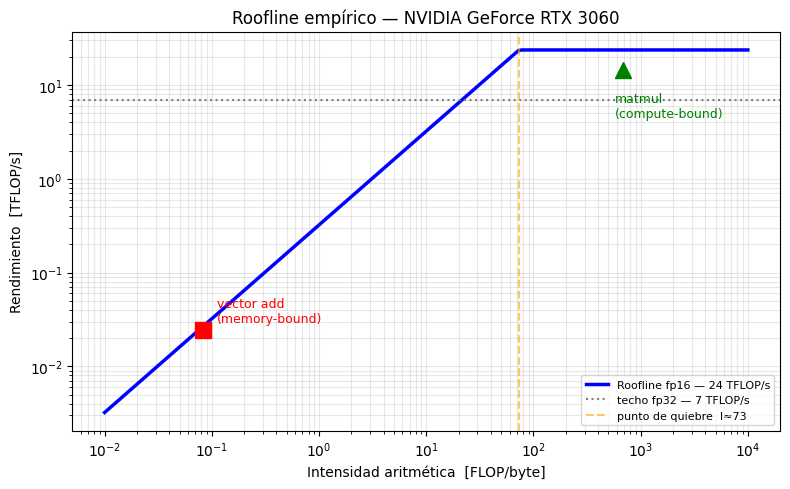

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1) LOS DOS TECHOS DEL SISTEMA (medidos, no teóricos) ──────────────────
techo_mem_GBs = BW_PICO          # rampa de memoria (medido en la sección 2)

def techo_computo(dtype, N=4096):
    """Mejor TFLOP/s alcanzable: matmul grande de cuBLAS satura el cómputo."""
    a = torch.randn((N, N), device=DEVICE, dtype=dtype)
    b = torch.randn((N, N), device=DEVICE, dtype=dtype)
    ms = triton.testing.do_bench(lambda: a @ b)
    return 2 * N**3 / (ms * 1e-3) / 1e12

techo_fp16 = techo_computo(torch.float16)   # usa Tensor Cores
techo_fp32 = techo_computo(torch.float32)   # usa CUDA cores
print(f"Techo de memoria  : {techo_mem_GBs:.0f} GB/s")
print(f"Techo cómputo fp16: {techo_fp16:.1f} TFLOP/s  (Tensor Cores)")
print(f"Techo cómputo fp32: {techo_fp32:.1f} TFLOP/s  (CUDA cores)")

# ── 2) NUESTROS KERNELS COMO PUNTOS (intensidad + rendimiento medido) ─────
# add: 1 FLOP/elemento, mueve 3 buffers de 4 bytes -> I = 1/12 FLOP/byte
n = 2**24
xa = torch.rand(n, device=DEVICE); ya = torch.rand(n, device=DEVICE)
t = triton.testing.do_bench(lambda: add(xa, ya))
I_add = 1 / 12
P_add = n / (t * 1e-3) / 1e12

# matmul didáctico (fp16, N=2048): FLOPs=2N^3 ; bytes DRAM ~ 3·N^2·2 -> I=N/3
N = 2048
am = torch.randn((N, N), device=DEVICE, dtype=torch.float16)
bm = torch.randn((N, N), device=DEVICE, dtype=torch.float16)
t = triton.testing.do_bench(lambda: matmul(am, bm))
I_mm = N / 3
P_mm = 2 * N**3 / (t * 1e-3) / 1e12
print(f"\nvector add: I = {I_add:.3f} FLOP/byte  |  {P_add*1e3:6.2f} GFLOP/s alcanzados")
print(f"matmul    : I = {I_mm:.0f} FLOP/byte    |  {P_mm:6.1f} TFLOP/s alcanzados")

# ── 3) DIBUJAR EL ROOFLINE ────────────────────────────────────────────────
I = np.logspace(-2, 4, 200)
pendiente = techo_mem_GBs / 1e3            # GB/s -> TFLOP/s por FLOP/byte
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(I, np.minimum(pendiente * I, techo_fp16), 'b-', lw=2.5,
        label=f'Roofline fp16 — {techo_fp16:.0f} TFLOP/s')
ax.axhline(techo_fp32, ls=':', color='gray',
           label=f'techo fp32 — {techo_fp32:.0f} TFLOP/s')
ridge = techo_fp16 * 1e3 / techo_mem_GBs
ax.axvline(ridge, ls='--', color='orange', alpha=.6,
           label=f'punto de quiebre  I≈{ridge:.0f}')
ax.plot(I_add, P_add, 'rs', ms=12)
ax.annotate('vector add\n(memory-bound)', (I_add, P_add),
            textcoords='offset points', xytext=(10, 6), fontsize=9, color='red')
ax.plot(I_mm, P_mm, 'g^', ms=12)
ax.annotate('matmul\n(compute-bound)', (I_mm, P_mm),
            textcoords='offset points', xytext=(-6, -34), fontsize=9, color='green')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Intensidad aritmética  [FLOP/byte]')
ax.set_ylabel('Rendimiento  [TFLOP/s]')
ax.set_title(f'Roofline empírico — {torch.cuda.get_device_name(0)}')
ax.grid(True, which='both', alpha=.3)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

## 11 · Resumen y *checklist* de profiling

El método, en orden:

1. **Mide bien.** Nunca `time.time()` a secas → usa `triton.testing.do_bench`
   (warmup, *CUDA events*, *flush* de L2, cuantiles).
2. **Clasifica el kernel.** ¿Memory-bound o compute-bound? Calcula la intensidad
   aritmética y compara contra el **techo** correspondiente (GB/s o TFLOP/s).
3. **Pon un número absoluto.** Convierte ms en GB/s o TFLOP/s y divídelo por el
   pico de tu GPU → *eficiencia %*. Eso te dice cuánto queda por ganar.
4. **Barre y compara.** `perf_report` contra una referencia (PyTorch/cuBLAS).
5. **Si hay brecha, abre el binario.** `n_regs`, `n_spills`, memoria compartida;
   prueba `BLOCK_SIZE` / `@triton.autotune`.
6. **Si hay varios kernels, mira el *timeline*.** `torch.profiler` → Perfetto.
7. **Para exprimir, usa Nsight** (`nsys` para el sistema, `ncu` para el kernel).

> **La regla de oro:** *no optimices a ciegas.* Mide primero, identifica el techo
> que te limita, y ataca solo eso. Optimizar lo que no es el cuello de botella es
> trabajo perdido.

---

### Para practicar

- Vuelve al `02_fused_softmax.py` del repo y **demuestra con `torch.profiler`** que
  la versión fusionada de Triton lanza **menos kernels** que `torch.softmax`.
- Añade `@triton.autotune` al `add_kernel` con varias `BLOCK_SIZE` y comprueba si
  iguala la mejor fila de la tabla de la sección 6.
- Amplía el **roofline** de la sección 10: añade un tercer punto (p. ej. el
  `matmul` de cuBLAS, o el *softmax* fusionado) y comprueba de qué lado del punto
  de quiebre cae cada kernel.